<a href="https://colab.research.google.com/github/zaporozhetsalena/My-first-project/blob/main/hw_11_2_matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/hometasks/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [5]:
monthly_avg = df["count"].resample("ME").mean()

In [6]:
monthly_avg.head()

,count
datetime,
2011-01-31,54.645012
2011-02-28,73.641256
2011-03-31,86.849776
2011-04-30,111.026374
2011-05-31,174.809211


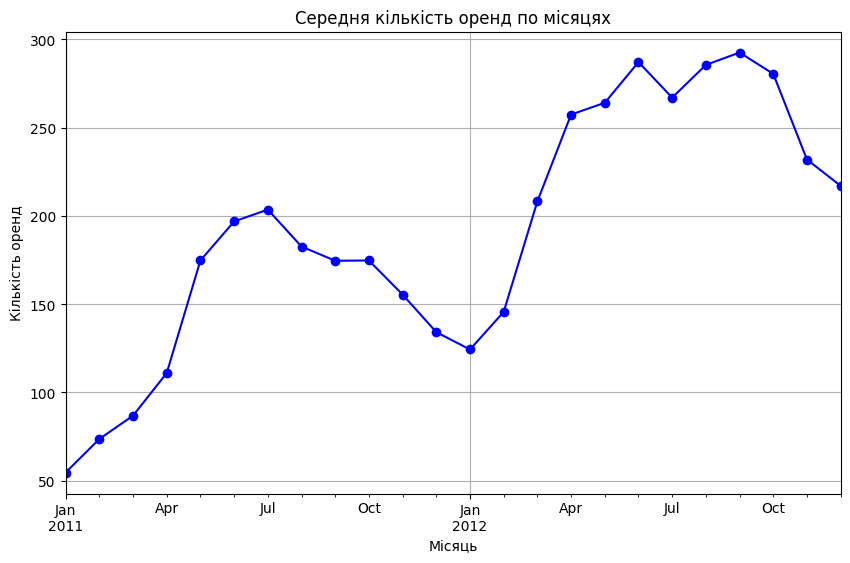

In [7]:
monthly_avg.plot(
    marker="o",
    figsize=(10,6),
    color="blue",
    title="Середня кількість оренд по місяцях",
    xlabel=("Місяць"),
    ylabel=("Кількість оренд"),
    grid=True
);


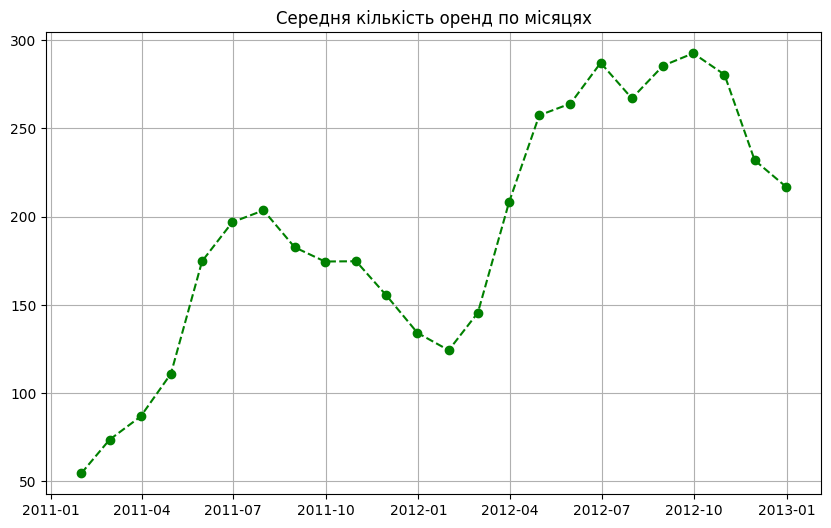

In [8]:
plt.figure(figsize=(10,6))
plt.plot(monthly_avg,"o--g")
plt.title("Середня кількість оренд по місяцях")
plt.xlabel=("Місяць"),
plt.ylabel=("Кількість оренд")
plt.grid(True);


## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [9]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

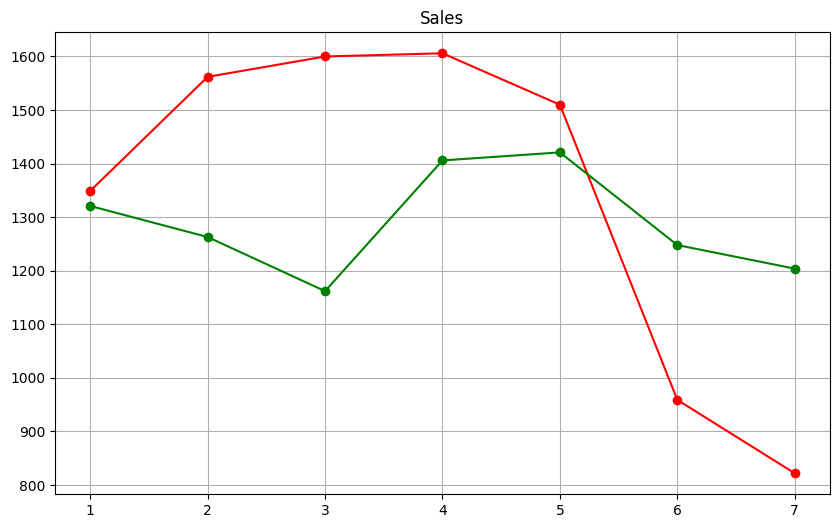

In [10]:
plt.figure(figsize=(10, 6))
plt.title("Sales")
plt.plot(days, sales_week1, marker='o', color='red', label='Тиждень 1')
plt.plot(days, sales_week2, marker='o', color='green', label='Тиждень 2')
plt.grid(True)
plt.show()

## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

In [11]:
monthly_temperature = df["count"].resample("ME").mean()

In [12]:
quarter_rentals = df['count'].resample('QE').mean()

In [13]:
humidity = df['humidity']

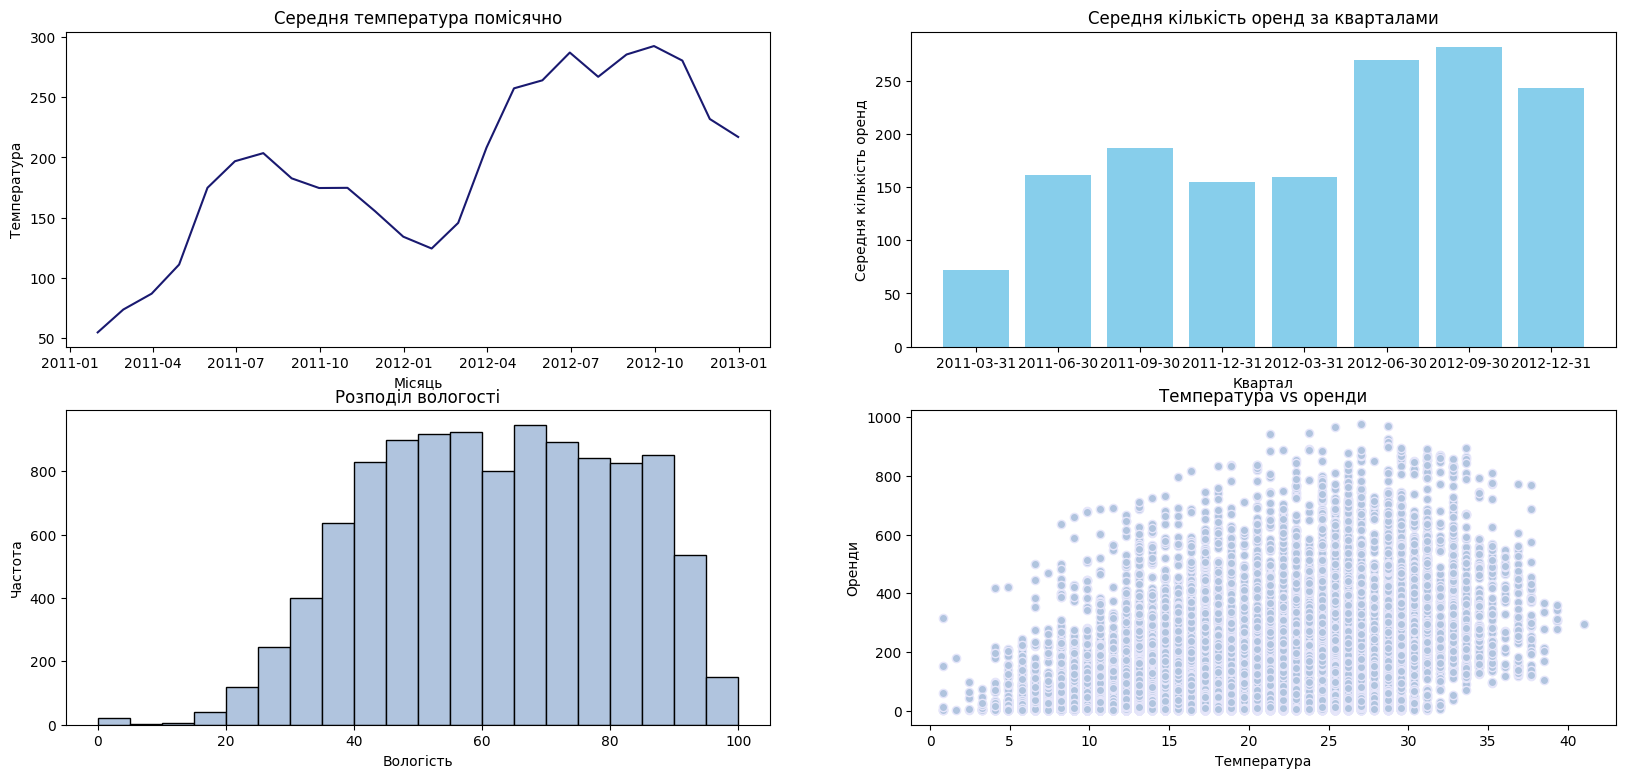

In [14]:
fig, ax = plt.subplots(2,2,figsize=(20,9))

# Графік 1
ax[0,0].plot(monthly_temperature.index, monthly_temperature.values, color='midnightblue')
ax[0,0].set_title("Середня температура помісячно")
ax[0,0].set_xlabel("Місяць")
ax[0,0].set_ylabel("Температура");

# Графік 2
ax[0,1].bar(quarter_rentals.index.astype(str),
    quarter_rentals.values,color='skyblue')
ax[0,1].set_title("Середня кількість оренд за кварталами")
ax[0,1].set_xlabel("Квартал")
ax[0,1].set_ylabel("Середня кількість оренд");

# Графік 3
ax[1,0].hist(humidity, bins=20, color='lightsteelblue',edgecolor='black')
ax[1,0].set_title("Розподіл вологості")
ax[1,0].set_xlabel("Вологість")
ax[1,0].set_ylabel("Частота");

# Графік 4
ax[1,1].scatter(df['temp'], df['count'],
                color='lightsteelblue',
                edgecolor='lavender')
ax[1,1].set_title("Температура vs оренди")
ax[1,1].set_xlabel("Температура")
ax[1,1].set_ylabel("Оренди");






In [15]:
df.head(2)


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,hour,weekday,weekday_num,week,year,day
datetime,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,1,0,Saturday,5,52,2011,1
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,1,Saturday,5,52,2011,1


## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

In [17]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

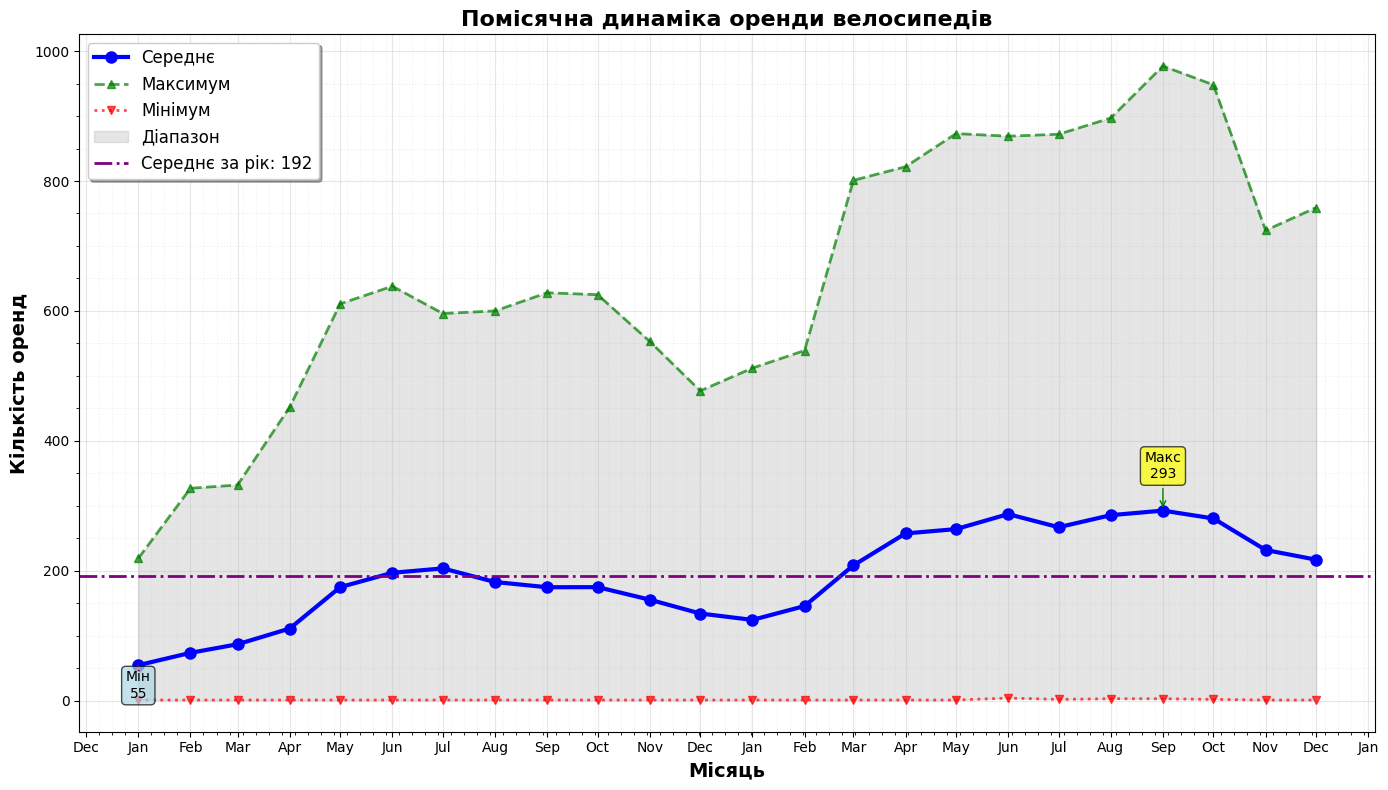

In [19]:
df.index = pd.to_datetime(df.index)
df['month'] = df.index.to_period('M')

monthly_stats = df.groupby('month')['count'].agg(['mean', 'max', 'min'])
monthly_stats.index = monthly_stats.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 8))

# Лінії
ax.plot(monthly_stats.index, monthly_stats['mean'], 'b-o',
        linewidth=3, label='Середнє', markersize=8)

ax.plot(monthly_stats.index, monthly_stats['max'], 'g--^',
        linewidth=2, label='Максимум', markersize=6, alpha=0.7)

ax.plot(monthly_stats.index, monthly_stats['min'], 'r:v',
        linewidth=2, label='Мінімум', markersize=6, alpha=0.7)

# Заливка
ax.fill_between(monthly_stats.index,
                monthly_stats['min'],
                monthly_stats['max'],
                alpha=0.2, color='gray', label='Діапазон')

# АНОТАЦІЯ MAX
max_idx = monthly_stats['mean'].idxmax()
max_val = monthly_stats['mean'].max()

ax.annotate(f'Макс\n{max_val:.0f}',
            xy=(max_idx, max_val),
            xytext=(max_idx, max_val + 50),
            arrowprops=dict(arrowstyle='->', color='green'),
            bbox=dict(boxstyle="round", facecolor='yellow', alpha=0.7),
            ha='center')

# АНОТАЦІЯ MIN
min_idx = monthly_stats['mean'].idxmin()
min_val = monthly_stats['mean'].min()

ax.annotate(f'Мін\n{min_val:.0f}',
            xy=(min_idx, min_val),
            xytext=(min_idx, min_val - 50),
            arrowprops=dict(arrowstyle='->', color='red'),
            bbox=dict(boxstyle="round", facecolor='lightblue', alpha=0.7),
            ha='center')

# СЕРЕДНЄ ЗА РІК
overall_mean = df['count'].mean()

ax.axhline(y=overall_mean,
           color='purple',
           linestyle='-.',
           linewidth=2,
           label=f'Середнє за рік: {overall_mean:.0f}')

# ОСІ
ax.set_xlabel("Місяць", fontsize=14, fontweight='bold')
ax.set_ylabel("Кількість оренд", fontsize=14, fontweight='bold')
ax.set_title("Помісячна динаміка оренди велосипедів",
             fontsize=16, fontweight='bold')

# ФОРМАТ ДАТ
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())

# СІТКА
ax.grid(True, which='major', linestyle='-', alpha=0.3)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.minorticks_on()

# ЛЕГЕНДА
ax.legend(loc='upper left', fontsize=12, shadow=True, fancybox=True)

# ТЕКСТ
text = f"Діапазон: {monthly_stats['min'].min():.0f} - {monthly_stats['max'].max():.0f}\n"
text += f"Середнє відхилення: {(monthly_stats['max'] - monthly_stats['min']).mean():.0f}"

ax.text(0.02, 0.95, text,
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

1. Яка перевага додавання анотацій на графік?

Анотації дозволяють виділити ключові точки на графіку (наприклад, максимум або мінімум), щоб:

швидко привернути увагу до важливих значень
зробити графік зрозумілішим без додаткового аналізу
підкреслити висновки прямо на візуалізації
2. Для чого використовується fill_between()?

fill_between() використовується для візуалізації діапазону між двома значеннями.
це допомагає показати варіативність даних,зрозуміти, наскільки сильно змінюються значення
візуально оцінити “розкид” даних

3.Як текстовий блок допомагає в інтерпретації даних? Текстовий блок додає ключову статистику прямо на графік, наприклад:загальний діапазон,середнє відхилення
Це дозволяє:

не рахувати нічого вручну
швидко отримати узагальнену інформацію
зробити графік самодостатнім (як у звітах)